In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
from scipy.optimize import least_squares
from scipy.integrate import cumulative_trapezoid
import math

In [3]:
def quaternion_to_euler(x, y, z, w):
    """
    Convert quaternion(s) into euler angles (roll, pitch, yaw)

    roll is rotation around x in radians (counterclockwise)
    pitch is rotation around y in radians (counterclockwise)
    yaw is rotation around z in radians (counterclockwise)
    """
    t0 = 2.0 * (w * x + y * z)
    t1 = 1.0 - 2.0 * (x * x + y * y)
    roll_x = np.arctan2(t0, t1)  
 
    t2 = 2.0 * (w * y - z * x)
    t2 = np.clip(t2, -1.0, 1.0)  
    pitch_y = np.arcsin(t2)  
 
    t3 = 2.0 * (w * z + x * y)
    t4 = 1.0 - 2.0 * (y * y + z * z)
    yaw_z = np.arctan2(t3, t4)  
 
    return roll_x, pitch_y, yaw_z  # in radians

def quaternion_array(w, x, y, z):
    q_array = np.array([w, x, y, z], dtype=float)
    return q_array

def quartenion_conj(q):
    return np.array([q[0], -q[1], -q[2], -q[3]])

def quaternion_mult(q1, q2):
    w1, x1, y1, z1 = q1
    w2, x2, y2, z2 = q2

    return np.array([
        w1 * w2 - x1 * x2 - y1 * y2 - z1 * z2,
        w1 * x2 + x1 * w2 + y1 * z2 - z1 * y2,
        w1 * y2 - x1 * z2 + y1 * w2 + z1 * x2,
        w1 * z2 + x1 * y2 - y1 * x2 + z1 * w2,
    ])

def quaternion_rotate(q, v):
    q = quaternion_normalize(q)
    v_q = np.array([0.0, v[0], v[1], v[2]])
    return quaternion_mult(quaternion_mult(q, v_q), quartenion_conj(q))[1:]

def quaternion_normalize(q):
    return q / np.linalg.norm(q)

# --- Angle Estimation Function ---
def angle_estimation(qA, qB):
    # Transform to world
    bone_axis = np.array([1.0, 0.0, 0.0])
    upper_world = quaternion_rotate(qA, bone_axis)
    forearm_world = quaternion_rotate(qB, bone_axis)

    # Make unit vectors
    upper_world /= np.linalg.norm(upper_world)
    forearm_world /= np.linalg.norm(forearm_world)

    # Arccos of dot product to get angle
    dot = float(np.dot(upper_world, forearm_world))
    dot = np.clip(dot, -1.0, 1.0)
    theta = np.arccos(dot)
    theta_deg = np.degrees(theta)

    return theta_deg

Complementary filter Data Extraction & Plotting

In [164]:
# Extract information from csv files
complementary_imu1_data = "complementary_filter_csv/imu1_data_compl_3.csv"
complementary_imu2_data = "complementary_filter_csv/imu2_data_compl_3.csv"

# Read csv file
compfil_imu1_df = pd.read_csv(complementary_imu1_data)
compfil_imu2_df = pd.read_csv(complementary_imu2_data)

# Truncate to the shorter length
min_length = min(len(compfil_imu1_df), len(compfil_imu2_df))
compfil_imu1_df = compfil_imu1_df.iloc[:min_length]
compfil_imu2_df = compfil_imu2_df.iloc[:min_length]

# Get timestamps
timestamp_sec = compfil_imu1_df['timestamp_sec'].values + compfil_imu1_df['timestamp_nsec'].values * 1e-9
time_relative = timestamp_sec - timestamp_sec[0]
dt = np.diff(timestamp_sec) # timestep

# IMU 1
quat_x_imu1 = compfil_imu1_df['orientation_x']
quat_y_imu1 = compfil_imu1_df['orientation_y']
quat_z_imu1 = compfil_imu1_df['orientation_z']
quat_w_imu1 = compfil_imu1_df['orientation_w']
# Convert to Euler angle (Roll, Pitch, Yaw)
roll_x1, pitch_y1, yaw_z1 = quaternion_to_euler(quat_x_imu1, quat_y_imu1, quat_z_imu1, quat_w_imu1)
# Convert from radian to degree unit
roll_euler_imu1 = roll_x1 * 180 / np.pi
pitch_euler_imu1 = pitch_y1 * 180 / np.pi
yaw_euler_imu1 = np.array(yaw_z1 * 180 / np.pi)

# Get angular velocity and convert to degree
gyro_x_imu1 = compfil_imu1_df['angular_velocity_x'].values * 180/np.pi
gyro_y_imu1 = compfil_imu1_df['angular_velocity_y'].values * 180/np.pi
gyro_z_imu1 = compfil_imu1_df['angular_velocity_z'].values * 180/np.pi
# Get linear acceleration
acc_x_imu1 = compfil_imu1_df['linear_acceleration_x'].values
acc_y_imu1 = compfil_imu1_df['linear_acceleration_y'].values
acc_z_imu1 = compfil_imu1_df['linear_acceleration_z'].values - 9.81

# IMU 2
quat_x_imu2 = compfil_imu2_df['orientation_x']
quat_y_imu2 = compfil_imu2_df['orientation_y']
quat_z_imu2 = compfil_imu2_df['orientation_z']
quat_w_imu2 = compfil_imu2_df['orientation_w']
# Convert to Euler angle (Roll, Pitch, Yaw)
roll_x2, pitch_y2, yaw_z2 = quaternion_to_euler(quat_x_imu2, quat_y_imu2, quat_z_imu2, quat_w_imu2)
# Convert from radian to degree unit
roll_euler_imu2 = roll_x2 * 180 / np.pi
pitch_euler_imu2 = pitch_y2 * 180 / np.pi
yaw_euler_imu2 = np.array(yaw_z2 * 180 / np.pi)

# Get angular velocity and convert to degree
gyro_x_imu2 = compfil_imu2_df['angular_velocity_x'].values * 180/np.pi
gyro_y_imu2 = compfil_imu2_df['angular_velocity_y'].values * 180/np.pi
gyro_z_imu2 = compfil_imu2_df['angular_velocity_z'].values * 180/np.pi
# Get linear acceleration
acc_x_imu2 = compfil_imu2_df['linear_acceleration_x'].values
acc_y_imu2 = compfil_imu2_df['linear_acceleration_y'].values
acc_z_imu2 = compfil_imu2_df['linear_acceleration_z'].values - 9.81

# Calculate relative angle 
# relative_yaw = yaw_euler_imu2[:-10] - yaw_euler_imu1
# relative_yaw = (relative_yaw + 180) % 360 - 180
# relative_yaw = abs(relative_yaw - relative_yaw[0])

# Calculate angle using quaternion
angle_deg = np.array([
    angle_estimation(
        quaternion_array(quat_w_imu1.iloc[i], quat_x_imu1.iloc[i], 
                        quat_y_imu1.iloc[i], quat_z_imu1.iloc[i]),
        quaternion_array(quat_w_imu2.iloc[i], quat_x_imu2.iloc[i], 
                        quat_y_imu2.iloc[i], quat_z_imu2.iloc[i])
    )
    for i in range(len(quat_w_imu1))
])
# Calibrate: subtract initial angle so it starts at 0
angle_start = angle_deg[0]
angle_calibrated = np.abs(angle_deg - angle_start)

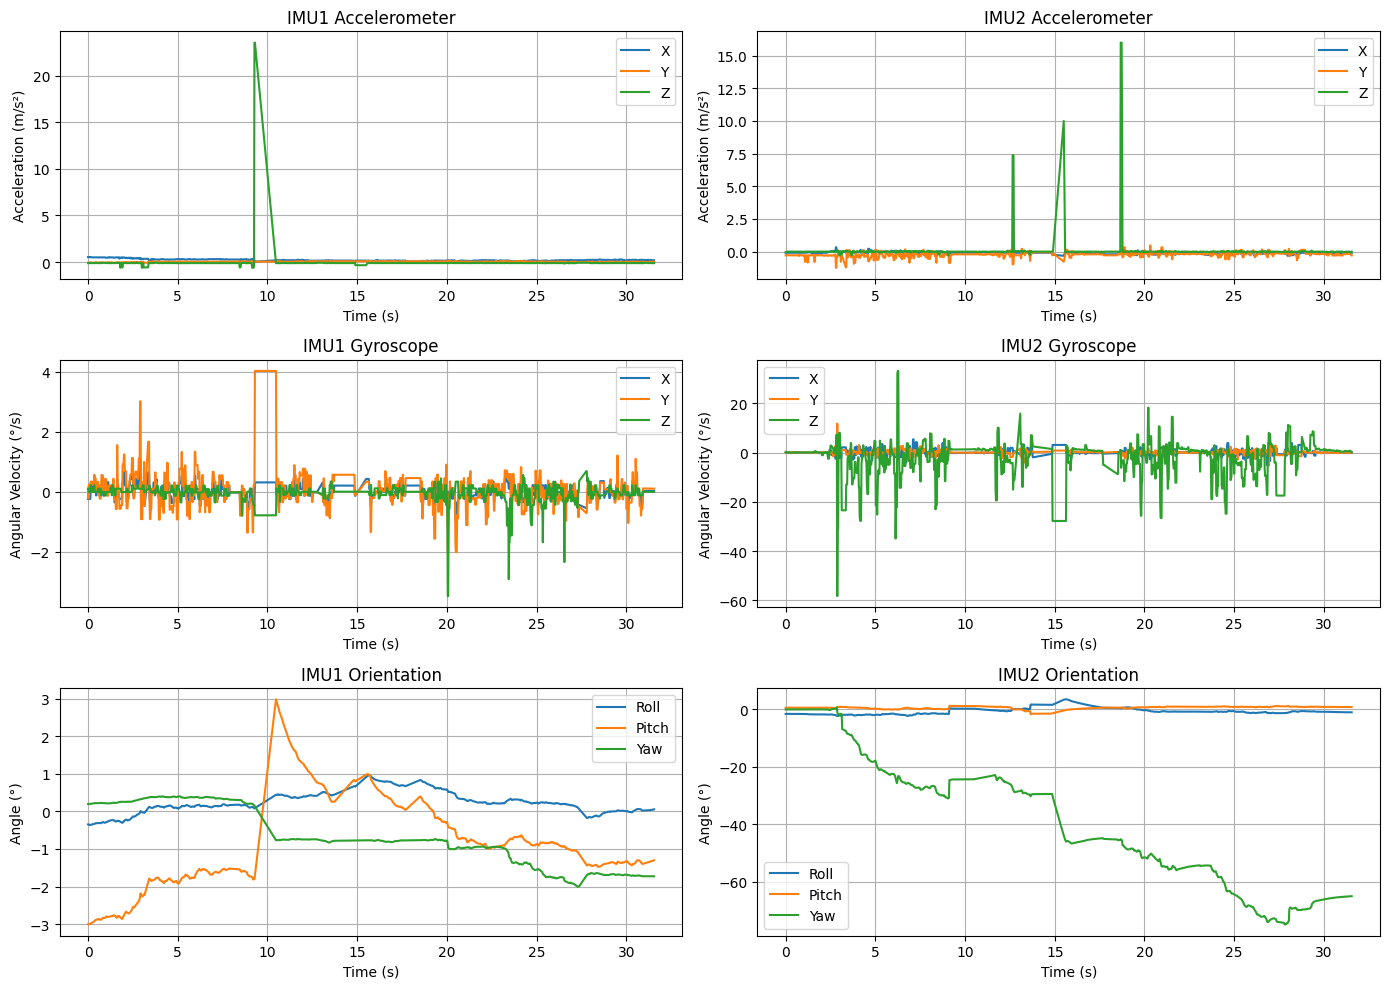

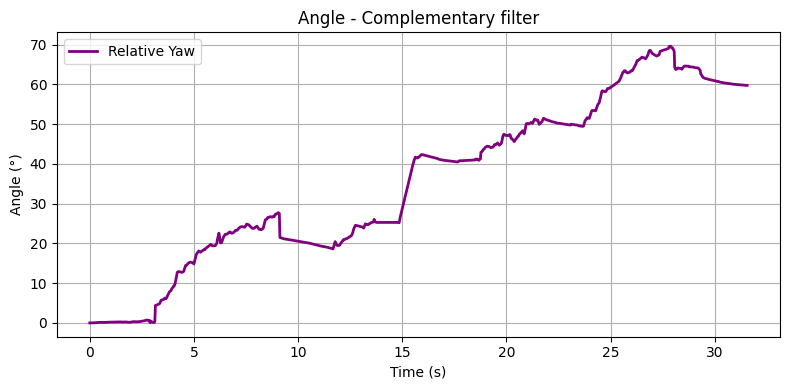

In [165]:
fig = plt.figure(figsize=(14, 10))
gs = GridSpec(3, 2, figure=fig)

# Row 0: Accelerometers
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(time_relative, acc_x_imu1, label='X')
ax1.plot(time_relative, acc_y_imu1, label='Y')
ax1.plot(time_relative, acc_z_imu1, label='Z')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Acceleration (m/s²)')
ax1.set_title('IMU1 Accelerometer')
ax1.legend()
ax1.grid(True)

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(time_relative, acc_x_imu2, label='X')
ax2.plot(time_relative, acc_y_imu2, label='Y')
ax2.plot(time_relative, acc_z_imu2, label='Z')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Acceleration (m/s²)')
ax2.set_title('IMU2 Accelerometer')
ax2.legend()
ax2.grid(True)

# Row 1: Gyroscopes
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(time_relative, gyro_x_imu1, label='X')
ax3.plot(time_relative, gyro_y_imu1, label='Y')
ax3.plot(time_relative, gyro_z_imu1, label='Z')
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Angular Velocity (°/s)')
ax3.set_title('IMU1 Gyroscope')
ax3.legend()
ax3.grid(True)

ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(time_relative, gyro_x_imu2, label='X')
ax4.plot(time_relative, gyro_y_imu2, label='Y')
ax4.plot(time_relative, gyro_z_imu2, label='Z')
ax4.set_xlabel('Time (s)')
ax4.set_ylabel('Angular Velocity (°/s)')
ax4.set_title('IMU2 Gyroscope')
ax4.legend()
ax4.grid(True)

# Row 2: Orientations
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(time_relative, roll_euler_imu1, label='Roll')
ax5.plot(time_relative, pitch_euler_imu1, label='Pitch')
ax5.plot(time_relative, yaw_euler_imu1, label='Yaw')
ax5.set_xlabel('Time (s)')
ax5.set_ylabel('Angle (°)')
ax5.set_title('IMU1 Orientation')
ax5.legend()
ax5.grid(True)

ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(time_relative, roll_euler_imu2, label='Roll')
ax6.plot(time_relative, pitch_euler_imu2, label='Pitch')
ax6.plot(time_relative, yaw_euler_imu2, label='Yaw')
ax6.set_xlabel('Time (s)')
ax6.set_ylabel('Angle (°)')
ax6.set_title('IMU2 Orientation')
ax6.legend()
ax6.grid(True)

plt.tight_layout()
plt.show()

# Separate figure for relative angle (makes it stand out)
fig2, ax7 = plt.subplots(figsize=(8, 4))
ax7.plot(time_relative, angle_calibrated, label='Relative Yaw', color='purple', linewidth=2)
ax7.set_xlabel('Time (s)')
ax7.set_ylabel('Angle (°)')
ax7.set_title('Angle - Complementary filter')
ax7.legend()
ax7.grid(True)
plt.tight_layout()
plt.show()

Madgwick filter Data Extraction & Plotting

In [8]:
# Extract information from csv files
madgwick_imu1_data = "madgwick_filter_csv/imu1_data_madgwick_6.csv"
madgwick_imu2_data = "madgwick_filter_csv/imu2_data_madgwick_6.csv"

# Read csv file
madgwick_imu1_df = pd.read_csv(madgwick_imu1_data)
madgwick_imu2_df = pd.read_csv(madgwick_imu2_data)

# Truncate to the shorter length
min_length = min(len(madgwick_imu1_df), len(madgwick_imu2_df))
madgwick_imu1_df = madgwick_imu1_df.iloc[:min_length]
madgwick_imu2_df = madgwick_imu2_df.iloc[:min_length]

# Get timestamps
timestamp_sec = madgwick_imu1_df['timestamp_sec'].values + madgwick_imu1_df['timestamp_nsec'].values * 1e-9
time_relative = timestamp_sec - timestamp_sec[0]
dt = np.diff(timestamp_sec) # timestep

# IMU 1
quat_x_imu1 = madgwick_imu1_df['orientation_x']
quat_y_imu1 = madgwick_imu1_df['orientation_y']
quat_z_imu1 = madgwick_imu1_df['orientation_z']
quat_w_imu1 = madgwick_imu1_df['orientation_w']
# Convert to Euler angle (Roll, Pitch, Yaw)
roll_x1, pitch_y1, yaw_z1 = quaternion_to_euler(quat_x_imu1, quat_y_imu1, quat_z_imu1, quat_w_imu1)
# Convert from radian to degree unit
roll_euler_imu1 = roll_x1 * 180 / np.pi
pitch_euler_imu1 = pitch_y1 * 180 / np.pi
yaw_euler_imu1 = np.array(yaw_z1 * 180 / np.pi)

# Get angular velocity and convert to degree
gyro_x_imu1 = madgwick_imu1_df['angular_velocity_x'].values * 180/np.pi
gyro_y_imu1 = madgwick_imu1_df['angular_velocity_y'].values * 180/np.pi
gyro_z_imu1 = madgwick_imu1_df['angular_velocity_z'].values * 180/np.pi
# Get linear acceleration
acc_x_imu1 = madgwick_imu1_df['linear_acceleration_x'].values
acc_y_imu1 = madgwick_imu1_df['linear_acceleration_y'].values
acc_z_imu1 = madgwick_imu1_df['linear_acceleration_z'].values

# IMU 2
quat_x_imu2 = madgwick_imu2_df['orientation_x']
quat_y_imu2 = madgwick_imu2_df['orientation_y']
quat_z_imu2 = madgwick_imu2_df['orientation_z']
quat_w_imu2 = madgwick_imu2_df['orientation_w']
# Convert to Euler angle (Roll, Pitch, Yaw)
roll_x2, pitch_y2, yaw_z2 = quaternion_to_euler(quat_x_imu2, quat_y_imu2, quat_z_imu2, quat_w_imu2)
# Convert from radian to degree unit
roll_euler_imu2 = roll_x2 * 180 / np.pi
pitch_euler_imu2 = pitch_y2 * 180 / np.pi
yaw_euler_imu2 = np.array(yaw_z2 * 180 / np.pi)

# Get angular velocity and convert to degree
gyro_x_imu2 = madgwick_imu2_df['angular_velocity_x'].values * 180/np.pi
gyro_y_imu2 = madgwick_imu2_df['angular_velocity_y'].values * 180/np.pi
gyro_z_imu2 = madgwick_imu2_df['angular_velocity_z'].values * 180/np.pi
# Get linear acceleration
acc_x_imu2 = madgwick_imu2_df['linear_acceleration_x'].values
acc_y_imu2 = madgwick_imu2_df['linear_acceleration_y'].values
acc_z_imu2 = madgwick_imu2_df['linear_acceleration_z'].values

# Calculate relative angle 
angle_degree = yaw_euler_imu2 - yaw_euler_imu1
angle_degree = (angle_deg + 180) % 360 - 180
angle_degree = abs(angle_deg - angle_deg[0])

# Calculate angle using quaternion
angle_deg = np.array([
    angle_estimation(
        quaternion_array(quat_w_imu1.iloc[i], quat_x_imu1.iloc[i], 
                        quat_y_imu1.iloc[i], quat_z_imu1.iloc[i]),
        quaternion_array(quat_w_imu2.iloc[i], quat_x_imu2.iloc[i], 
                        quat_y_imu2.iloc[i], quat_z_imu2.iloc[i])
    )
    for i in range(len(quat_w_imu1))
])
# Calibrate: subtract initial angle so it starts at 0
angle_start = angle_deg[0]
angle_calibrated = np.abs(angle_deg - angle_start)

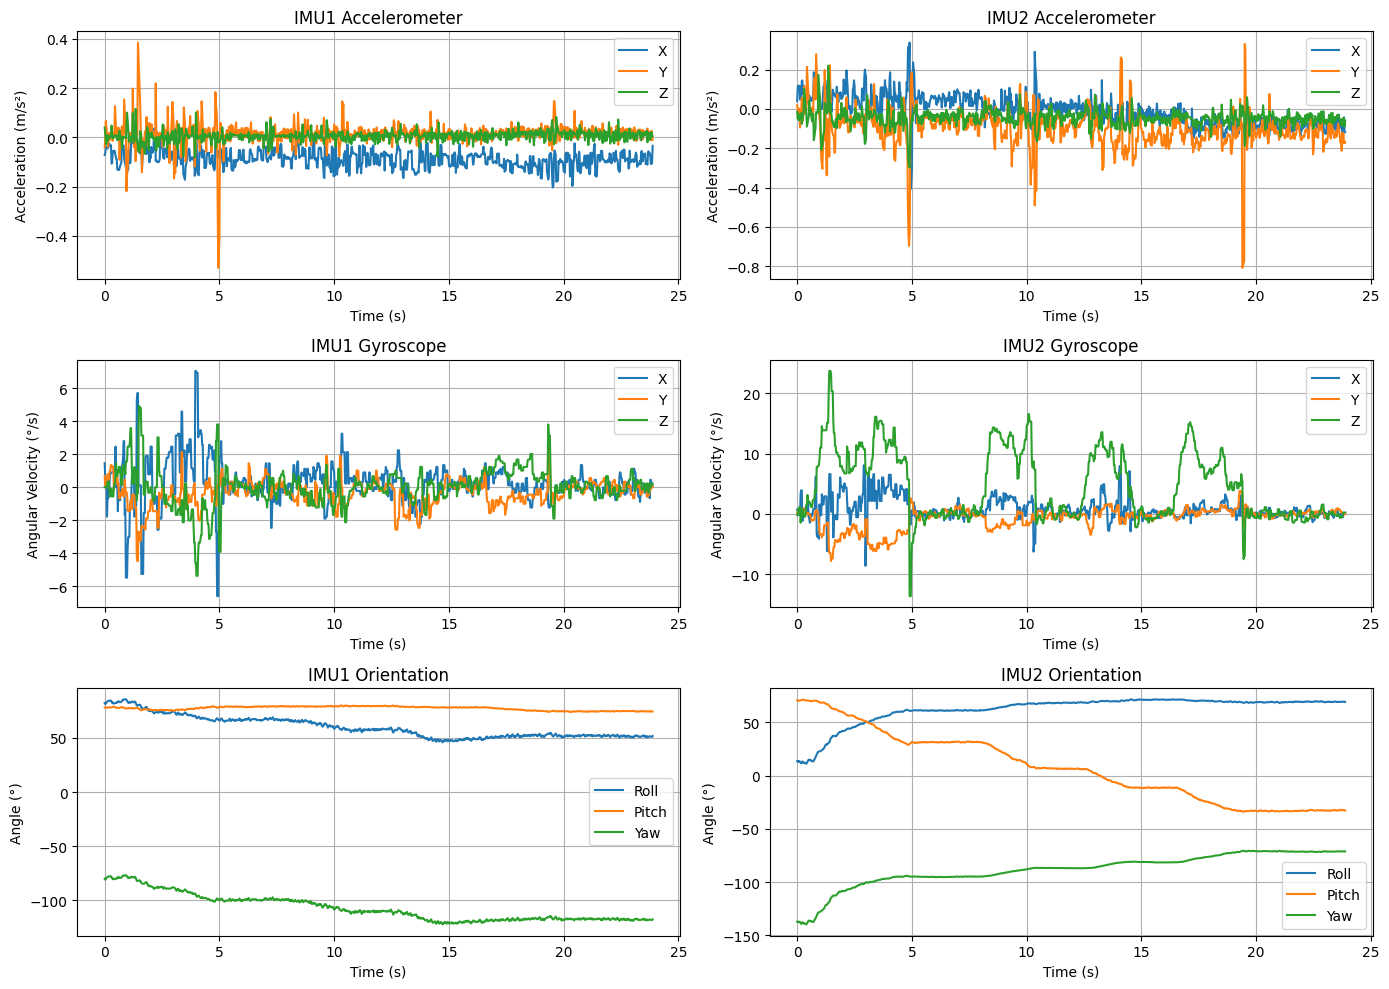

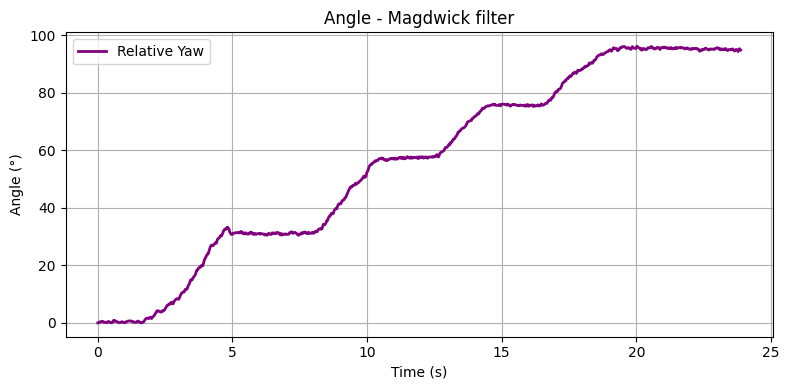

In [ ]:
fig = plt.figure(figsize=(14, 10))
gs = GridSpec(3, 2, figure=fig)

# Row 0: Accelerometers
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(time_relative, acc_x_imu1, label='X')
ax1.plot(time_relative, acc_y_imu1, label='Y')
ax1.plot(time_relative, acc_z_imu1, label='Z')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Acceleration (m/s²)')
ax1.set_title('IMU1 Accelerometer')
ax1.legend()
ax1.grid(True)

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(time_relative, acc_x_imu2, label='X')
ax2.plot(time_relative, acc_y_imu2, label='Y')
ax2.plot(time_relative, acc_z_imu2, label='Z')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Acceleration (m/s²)')
ax2.set_title('IMU2 Accelerometer')
ax2.legend()
ax2.grid(True)

# Row 1: Gyroscopes
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(time_relative, gyro_x_imu1, label='X')
ax3.plot(time_relative, gyro_y_imu1, label='Y')
ax3.plot(time_relative, gyro_z_imu1, label='Z')
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Angular Velocity (°/s)')
ax3.set_title('IMU1 Gyroscope')
ax3.legend()
ax3.grid(True)

ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(time_relative, gyro_x_imu2, label='X')
ax4.plot(time_relative, gyro_y_imu2, label='Y')
ax4.plot(time_relative, gyro_z_imu2, label='Z')
ax4.set_xlabel('Time (s)')
ax4.set_ylabel('Angular Velocity (°/s)')
ax4.set_title('IMU2 Gyroscope')
ax4.legend()
ax4.grid(True)

# Row 2: Orientations
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(time_relative, roll_euler_imu1, label='Roll')
ax5.plot(time_relative, pitch_euler_imu1, label='Pitch')
ax5.plot(time_relative, yaw_euler_imu1, label='Yaw')
ax5.set_xlabel('Time (s)')
ax5.set_ylabel('Angle (°)')
ax5.set_title('IMU1 Orientation')
ax5.legend()
ax5.grid(True)

ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(time_relative, roll_euler_imu2, label='Roll')
ax6.plot(time_relative, pitch_euler_imu2, label='Pitch')
ax6.plot(time_relative, yaw_euler_imu2, label='Yaw')
ax6.set_xlabel('Time (s)')
ax6.set_ylabel('Angle (°)')
ax6.set_title('IMU2 Orientation')
ax6.legend()
ax6.grid(True)

plt.tight_layout()
plt.show()

# Separate figure for relative angle (makes it stand out)
fig2, ax7 = plt.subplots(figsize=(8, 4))
ax7.plot(time_relative, angle_calibrated, label='Relative Yaw', color='purple', linewidth=2)
ax7.set_xlabel('Time (s)')
ax7.set_ylabel('Angle (°)')
ax7.set_title('Angle - Magdwick filter')
ax7.legend()
ax7.grid(True)
plt.tight_layout()
plt.show()

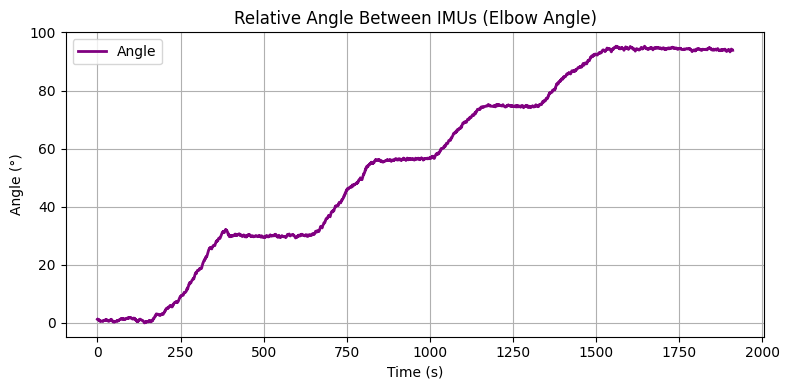

In [130]:
# Extract information from csv files
madgwick_angle = "madgwick_filter_csv/angle_madgwick_6.csv"

# Read csv file
madgwick_angle_df = pd.read_csv(madgwick_angle)

# Extract angle from csv file
angle = madgwick_angle_df['estimated_angle']

# Plot
fig = plt.figure(figsize=(8, 4))
plt.plot(angle, label='Angle', color='purple', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Angle (°)')
plt.title('Relative Angle Between IMUs (Elbow Angle)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



Sparkfun library

In [155]:
# Extract information from csv files
sparkfun_imu1_data = "sparkfun_csv/imu1_sparkfun_test.csv"
sparkfun_imu2_data = "sparkfun_csv/imu2_sparkfun_test.csv"

# Read csv file
sparkfun_imu1_df = pd.read_csv(sparkfun_imu1_data)
sparkfun_imu2_df = pd.read_csv(sparkfun_imu2_data)

# Truncate to the shorter length
min_length = min(len(sparkfun_imu1_df), len(sparkfun_imu2_df))
sparkfun_imu1_df = sparkfun_imu1_df.iloc[:min_length]
sparkfun_imu2_df = sparkfun_imu2_df.iloc[:min_length]

# Get timestamps
timestamp_sec = sparkfun_imu1_df['timestamp_sec'].values + sparkfun_imu1_df['timestamp_nsec'].values * 1e-9
time_relative = timestamp_sec - timestamp_sec[0]
dt = np.diff(timestamp_sec) # timestep

# IMU 1
quat_x_imu1 = sparkfun_imu1_df['orientation_x']
quat_y_imu1 = sparkfun_imu1_df['orientation_y']
quat_z_imu1 = sparkfun_imu1_df['orientation_z']
quat_w_imu1 = sparkfun_imu1_df['orientation_w']
# Convert to Euler angle (Roll, Pitch, Yaw)
roll_x1, pitch_y1, yaw_z1 = quaternion_to_euler(quat_x_imu1, quat_y_imu1, quat_z_imu1, quat_w_imu1)
# Convert from radian to degree unit
roll_euler_imu1 = roll_x1 * 180 / np.pi
pitch_euler_imu1 = pitch_y1 * 180 / np.pi
yaw_euler_imu1 = np.array(yaw_z1 * 180 / np.pi)
# Get angular velocity and convert to degree
gyro_x_imu1 = sparkfun_imu1_df['angular_velocity_x'].values * 180/np.pi
gyro_y_imu1 = sparkfun_imu1_df['angular_velocity_y'].values * 180/np.pi
gyro_z_imu1 = sparkfun_imu1_df['angular_velocity_z'].values * 180/np.pi
# Get linear acceleration
acc_x_imu1 = sparkfun_imu1_df['linear_acceleration_x'].values
acc_y_imu1 = sparkfun_imu1_df['linear_acceleration_y'].values
acc_z_imu1 = sparkfun_imu1_df['linear_acceleration_z'].values - 9.81

# IMU 2
quat_x_imu2 = sparkfun_imu2_df['orientation_x']
quat_y_imu2 = sparkfun_imu2_df['orientation_y']
quat_z_imu2 = sparkfun_imu2_df['orientation_z']
quat_w_imu2 = sparkfun_imu2_df['orientation_w']
# Convert to Euler angle (Roll, Pitch, Yaw)
roll_x2, pitch_y2, yaw_z2 = quaternion_to_euler(quat_x_imu2, quat_y_imu2, quat_z_imu2, quat_w_imu2)
# Convert from radian to degree unit
roll_euler_imu2 = roll_x2 * 180 / np.pi
pitch_euler_imu2 = pitch_y2 * 180 / np.pi
yaw_euler_imu2 = np.array(yaw_z2 * 180 / np.pi)
# Get angular velocity and convert to degree
gyro_x_imu2 = sparkfun_imu2_df['angular_velocity_x'].values * 180/np.pi
gyro_y_imu2 = sparkfun_imu2_df['angular_velocity_y'].values * 180/np.pi
gyro_z_imu2 = sparkfun_imu2_df['angular_velocity_z'].values * 180/np.pi
# Get linear acceleration
acc_x_imu2 = sparkfun_imu2_df['linear_acceleration_x'].values
acc_y_imu2 = sparkfun_imu2_df['linear_acceleration_y'].values
acc_z_imu2 = sparkfun_imu2_df['linear_acceleration_z'].values - 9.81

# Calculate relative angle 
# relative_yaw = yaw_euler_imu2 - yaw_euler_imu1
# relative_yaw = (relative_yaw + 180) % 360 - 180
# relative_yaw = abs(relative_yaw - relative_yaw[0])

# Calculate angle using quaternion
angle_deg = np.array([
    angle_estimation(
        quaternion_array(quat_w_imu1.iloc[i], quat_x_imu1.iloc[i], 
                        quat_y_imu1.iloc[i], quat_z_imu1.iloc[i]),
        quaternion_array(quat_w_imu2.iloc[i], quat_x_imu2.iloc[i], 
                        quat_y_imu2.iloc[i], quat_z_imu2.iloc[i])
    )
    for i in range(len(quat_w_imu1))
])
# Calibrate: subtract initial angle so it starts at 0
angle_start = angle_deg[0]
angle_calibrated = np.abs(angle_deg - angle_start)

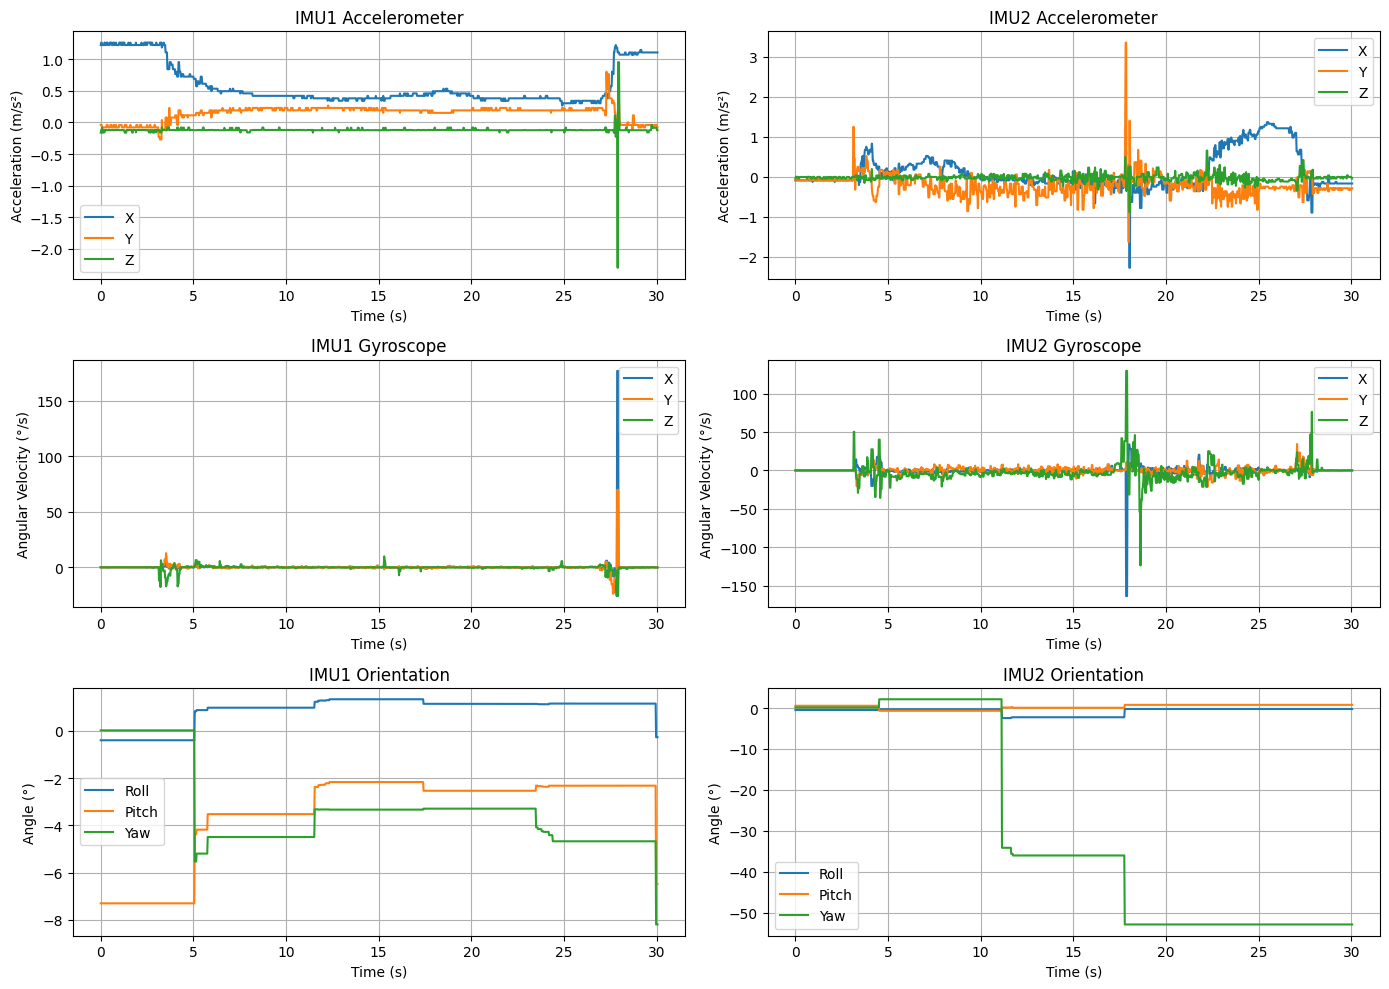

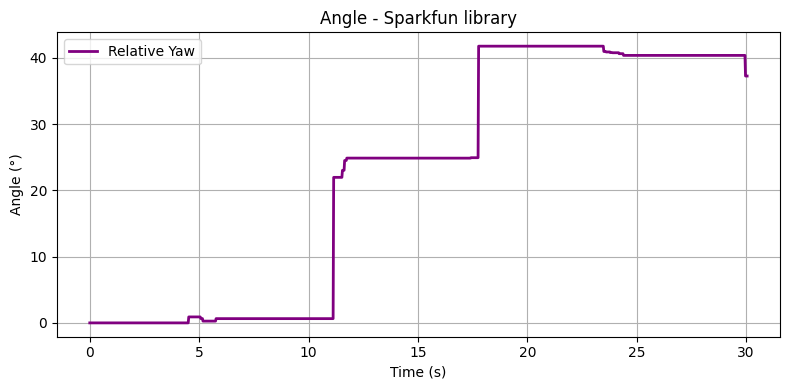

In [156]:
fig = plt.figure(figsize=(14, 10))
gs = GridSpec(3, 2, figure=fig)

# Row 0: Accelerometers
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(time_relative, acc_x_imu1, label='X')
ax1.plot(time_relative, acc_y_imu1, label='Y')
ax1.plot(time_relative, acc_z_imu1, label='Z')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Acceleration (m/s²)')
ax1.set_title('IMU1 Accelerometer')
ax1.legend()
ax1.grid(True)

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(time_relative, acc_x_imu2, label='X')
ax2.plot(time_relative, acc_y_imu2, label='Y')
ax2.plot(time_relative, acc_z_imu2, label='Z')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Acceleration (m/s²)')
ax2.set_title('IMU2 Accelerometer')
ax2.legend()
ax2.grid(True)

# Row 1: Gyroscopes
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(time_relative, gyro_x_imu1, label='X')
ax3.plot(time_relative, gyro_y_imu1, label='Y')
ax3.plot(time_relative, gyro_z_imu1, label='Z')
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Angular Velocity (°/s)')
ax3.set_title('IMU1 Gyroscope')
ax3.legend()
ax3.grid(True)

ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(time_relative, gyro_x_imu2, label='X')
ax4.plot(time_relative, gyro_y_imu2, label='Y')
ax4.plot(time_relative, gyro_z_imu2, label='Z')
ax4.set_xlabel('Time (s)')
ax4.set_ylabel('Angular Velocity (°/s)')
ax4.set_title('IMU2 Gyroscope')
ax4.legend()
ax4.grid(True)

# Row 2: Orientations
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(time_relative, roll_euler_imu1, label='Roll')
ax5.plot(time_relative, pitch_euler_imu1, label='Pitch')
ax5.plot(time_relative, yaw_euler_imu1, label='Yaw')
ax5.set_xlabel('Time (s)')
ax5.set_ylabel('Angle (°)')
ax5.set_title('IMU1 Orientation')
ax5.legend()
ax5.grid(True)

ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(time_relative, roll_euler_imu2, label='Roll')
ax6.plot(time_relative, pitch_euler_imu2, label='Pitch')
ax6.plot(time_relative, yaw_euler_imu2, label='Yaw')
ax6.set_xlabel('Time (s)')
ax6.set_ylabel('Angle (°)')
ax6.set_title('IMU2 Orientation')
ax6.legend()
ax6.grid(True)

plt.tight_layout()
plt.show()

# Separate figure for relative angle (makes it stand out)
fig2, ax7 = plt.subplots(figsize=(8, 4))
ax7.plot(time_relative, angle_calibrated, label='Relative Yaw', color='purple', linewidth=2)
ax7.set_xlabel('Time (s)')
ax7.set_ylabel('Angle (°)')
ax7.set_title('Angle - Sparkfun library')
ax7.legend()
ax7.grid(True)
plt.tight_layout()
plt.show()